RECTANGLE

Dataset Generation + Logistic Regression

Starting Logistic Regression (Baseline) on RECTANGLE...
Processing Round 1...
Round 1 | Bitwise Accuracy: 0.6221 | Avg Hamming Distance: 24.19/64
Processing Round 2...
Round 2 | Bitwise Accuracy: 0.5307 | Avg Hamming Distance: 30.03/64
Processing Round 3...
Round 3 | Bitwise Accuracy: 0.5045 | Avg Hamming Distance: 31.71/64
Processing Round 4...
Round 4 | Bitwise Accuracy: 0.5017 | Avg Hamming Distance: 31.89/64


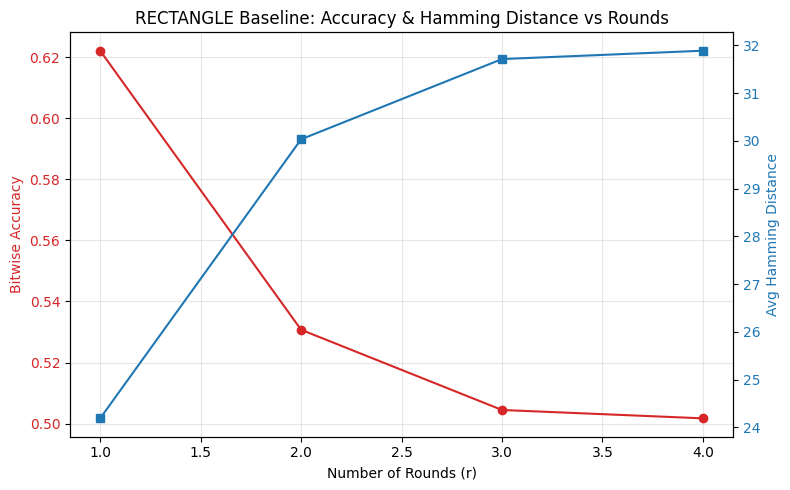

In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

SBOX = [0x6, 0x5, 0xc, 0xa, 0x1, 0xe, 0x7, 0x9, 0xb, 0x0, 0x3, 0x4, 0x8, 0xd, 0x2, 0xf]

def rectangle_round(state, round_key):
    state = [s ^ k for s, k in zip(state, round_key)]

    # SubColumn (S-box layer)
    new_state = [0] * 4
    for i in range(16):
        col = ((state[3] >> i) & 1) << 3 | \
              ((state[2] >> i) & 1) << 2 | \
              ((state[1] >> i) & 1) << 1 | \
              ((state[0] >> i) & 1)

        lookup = SBOX[col]
        for row in range(4):
            new_state[row] |= ((lookup >> row) & 1) << i

    # ShiftRow (Rotations)
    new_state[1] = ((new_state[1] << 1) & 0xFFFF) | (new_state[1] >> 15)
    new_state[2] = ((new_state[2] << 12) & 0xFFFF) | (new_state[2] >> 4)
    new_state[3] = ((new_state[3] << 13) & 0xFFFF) | (new_state[3] >> 3)

    return new_state

def generate_data(samples, rounds):
    X_bits = []
    Y_bits = []
    keys = [[0x1234, 0x5678, 0x9ABC, 0xDEF0] for _ in range(rounds)]

    for _ in range(samples):
        pt = [np.random.randint(0, 0xFFFF) for _ in range(4)]
        state = pt[:]
        for r in range(rounds):
            state = rectangle_round(state, keys[r])

        x_row = []
        y_row = []
        for i in range(4):
            x_row.extend([int(b) for b in format(pt[i], '016b')])
            y_row.extend([int(b) for b in format(state[i], '016b')])
        X_bits.append(x_row)
        Y_bits.append(y_row)

    return np.array(X_bits), np.array(Y_bits)

rounds_to_test = [1, 2, 3, 4]
samples = 10000 # Reduced slightly for faster baseline execution
results_acc = []
results_ham = []

print("Starting Logistic Regression (Baseline) on RECTANGLE...")

for r in rounds_to_test:
    print(f"Processing Round {r}...")
    X, Y = generate_data(samples, r)

    split = int(samples * 0.8)
    X_train, X_test = X[:split], X[split:]
    Y_train, Y_test = Y[:split], Y[split:]

    model = MultiOutputClassifier(LogisticRegression(solver='liblinear', max_iter=100))
    model.fit(X_train, Y_train)

    preds = model.predict(X_test)

    # 1. Bitwise Accuracy
    acc = accuracy_score(Y_test.flatten(), preds.flatten())
    results_acc.append(acc)

    # 2. Hamming Distance Calculation
    # We XOR (or check inequality) and sum the differences across the bit columns
    bitwise_diff = (preds != Y_test)
    # Average number of wrong bits per 64-bit sample
    avg_hamming = np.mean(np.sum(bitwise_diff, axis=1))
    results_ham.append(avg_hamming)

    print(f"Round {r} | Bitwise Accuracy: {acc:.4f} | Avg Hamming Distance: {avg_hamming:.2f}/64")

# Visualization
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:red'
ax1.set_xlabel('Number of Rounds (r)')
ax1.set_ylabel('Bitwise Accuracy', color=color)
ax1.plot(rounds_to_test, results_acc, marker='o', color=color, label='Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:blue'
ax2.set_ylabel('Avg Hamming Distance', color=color)
ax2.plot(rounds_to_test, results_ham, marker='s', color=color, label='Hamming')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("RECTANGLE Baseline: Accuracy & Hamming Distance vs Rounds")
fig.tight_layout()
plt.show()

Dataset + CNN model

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Detect GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SBOX = [0x6, 0x5, 0xC, 0xA, 0x1, 0xE, 0x7, 0x9, 0xB, 0x0, 0x3, 0xD, 0x8, 0xF, 0x4, 0x2]

def sbox_layer(state):
    output = 0
    for i in range(8):
        nibble = (state >> (4*i)) & 0xF
        output |= SBOX[nibble] << (4*i)
    return output

def permute(state):
    bits = [int(b) for b in format(state, '032b')]
    perm = bits[::2] + bits[1::2]
    return int("".join(map(str, perm)), 2)

def rectangle_encrypt(p, key, rounds):
    state = p
    for _ in range(rounds):
        state ^= (key & 0xFFFFFFFF)
        state = sbox_layer(state)
        state = permute(state)
    return state

def int_to_bits(x, bits=32):
    return [int(b) for b in format(x, f'0{bits}b')]

def generate_dataset(samples, rounds, key):
    X, Y = [], []
    delta = 0x0000000F
    for _ in range(samples):
        p1 = random.getrandbits(32)
        p2 = p1 ^ delta
        c1 = rectangle_encrypt(p1, key, rounds)
        c2 = rectangle_encrypt(p2, key, rounds)
        X.append(int_to_bits(p1 ^ p2))
        Y.append(int_to_bits(c1 ^ c2))
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

class RectangleCNN(nn.Module):
    def __init__(self):
        super(RectangleCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 32, 128)
        self.fc2 = nn.Linear(128, 32)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

def train_model(X, Y, round_num):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

    # Prepare GPU Tensors
    X_train = torch.tensor(X_train).unsqueeze(1).to(device)
    Y_train = torch.tensor(Y_train).to(device)
    X_test = torch.tensor(X_test).unsqueeze(1).to(device)
    Y_test = torch.tensor(Y_test).to(device)

    loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=512, shuffle=True)

    model = RectangleCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    for epoch in range(15):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    # SAVE MODEL WEIGHTS
    torch.save(model.state_dict(), f"rectangle_r{round_num}.pth")
    print(f"Model saved: rectangle_r{round_num}.pth")

    model.eval()
    with torch.no_grad():
        preds = (model(X_test) > 0.5).float()
        accuracy = (preds == Y_test).float().mean().item()
        hamming = torch.mean(torch.sum(preds != Y_test, dim=1).float()).item()

    return accuracy, hamming

if __name__ == "__main__":
    fixed_key = 0x123456789ABCDEF0 # Use a fixed key for consistency
    for r in range(1, 6):
        print(f"\n--- Training Round {r} ---")
        X, Y = generate_dataset(40000, r, fixed_key)
        acc, ham = train_model(X, Y, r)
        print(f"Accuracy: {acc:.4f}, Hamming: {ham:.4f}")

Using device: cuda

--- Training Round 1 ---
Model saved: rectangle_r1.pth
Accuracy: 0.9454, Hamming: 1.7460

--- Training Round 2 ---
Model saved: rectangle_r2.pth
Accuracy: 0.9005, Hamming: 3.1826

--- Training Round 3 ---
Model saved: rectangle_r3.pth
Accuracy: 0.7907, Hamming: 6.6969

--- Training Round 4 ---
Model saved: rectangle_r4.pth
Accuracy: 0.6168, Hamming: 12.2635

--- Training Round 5 ---
Model saved: rectangle_r5.pth
Accuracy: 0.5467, Hamming: 14.5064


Dataset generation + MLP model

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

MASK = 0xFFFFFFFF
SBOX = [0x6, 0x5, 0xC, 0xA, 0x1, 0xE, 0x7, 0x9, 0xB, 0x0, 0x3, 0xD, 0x8, 0xF, 0x4, 0x2]

def sbox_layer(state):
    output = 0
    for i in range(8):
        nibble = (state >> (4*i)) & 0xF
        output |= SBOX[nibble] << (4*i)
    return output

def permute(state):
    bits = [int(b) for b in format(state, '032b')]
    perm = bits[::2] + bits[1::2]
    return int("".join(map(str, perm)), 2)

def rectangle_encrypt(p, key, rounds):
    state = p
    for _ in range(rounds):
        state = (state ^ (key & MASK)) & MASK
        state = sbox_layer(state)
        state = permute(state)
    return state

def int_to_bits(x, bits=32):
    return [int(b) for b in format(x, f'0{bits}b')]

def generate_dataset(samples, rounds, key):
    X, Y = [], []
    delta = 0x0000000F
    for _ in range(samples):
        p1 = random.getrandbits(32)
        p2 = p1 ^ delta
        c1 = rectangle_encrypt(p1, key, rounds)
        c2 = rectangle_encrypt(p2, key, rounds)
        X.append(int_to_bits(p1 ^ p2))
        Y.append(int_to_bits(c1 ^ c2))
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

class RectangleMLP(nn.Module):
    def __init__(self):
        super(RectangleMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.Sigmoid() # Binary output for bits
        )

    def forward(self, x):
        return self.layers(x)

def train_and_evaluate(X, Y):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

    # Convert to Tensors
    X_train_t = torch.tensor(X_train)
    Y_train_t = torch.tensor(Y_train)
    X_test_t = torch.tensor(X_test).to(device)
    Y_test_t = torch.tensor(Y_test).to(device)

    train_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=512, shuffle=True)

    model = RectangleMLP().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training Loop
    model.train()
    for epoch in range(50): # Increased slightly for convergence
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    with torch.no_grad():
        preds = (model(X_test_t) > 0.5).float()
        accuracy = (preds == Y_test_t).float().mean().item()
        hamming = torch.mean(torch.sum(preds != Y_test_t, dim=1).float()).item()

    return accuracy, hamming

if __name__ == "__main__":
    key = random.getrandbits(64)
    samples = 40000

    for r in range(1, 6):
        print(f"\nRound {r} (GPU)")
        X, Y = generate_dataset(samples, r, key)
        acc, ham = train_and_evaluate(X, Y)
        print(f"Accuracy: {acc:.4f}")
        print(f"Hamming Distance: {ham:.4f}")

Using device: cuda

Round 1 (GPU)
Accuracy: 0.9454
Hamming Distance: 1.7463

Round 2 (GPU)
Accuracy: 0.8847
Hamming Distance: 3.6899

Round 3 (GPU)
Accuracy: 0.7932
Hamming Distance: 6.6161

Round 4 (GPU)
Accuracy: 0.6077
Hamming Distance: 12.5545

Round 5 (GPU)
Accuracy: 0.5411
Hamming Distance: 14.6850


Generalization


Round      | Unseen Data Accuracy
-----------------------------------
Round 1     | 0.9452
Round 2     | 0.9006
Round 3     | 0.7918
Round 4     | 0.6143
Round 5     | 0.5463


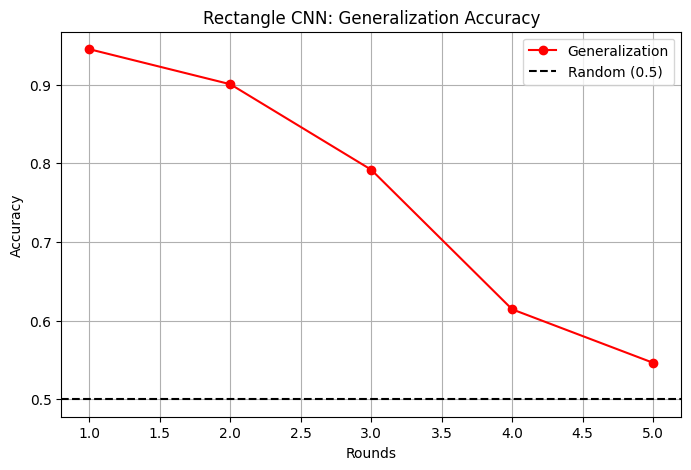

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ... (Paste the RectangleCNN class and encryption functions from above here) ...

def run_generalization():
    key = 0x123456789ABCDEF0
    rounds = range(1, 6)
    gen_accs = []

    print(f"\n{'Round':<10} | {'Unseen Data Accuracy':<20}")
    print("-" * 35)

    for r in rounds:
        try:
            # 1. Generate NEW data the model has never seen
            X_unseen, Y_unseen = generate_dataset(5000, r, key)
            X_t = torch.tensor(X_unseen).unsqueeze(1).to(device)
            Y_t = torch.tensor(Y_unseen).to(device)

            # 2. Load the specific model for this round
            model = RectangleCNN().to(device)
            model.load_state_dict(torch.load(f"rectangle_r{r}.pth", map_location=device))
            model.eval()

            # 3. Test bitwise accuracy
            with torch.no_grad():
                preds = (model(X_t) > 0.5).float()
                acc = (preds == Y_t).float().mean().item()
                gen_accs.append(acc)
                print(f"Round {r:<5} | {acc:.4f}")

        except FileNotFoundError:
            print(f"Round {r:<5} | Model file not found.")

    # Plotting
    plt.figure(figsize=(8,5))
    plt.plot(list(rounds), gen_accs, marker='o', color='red', label='Generalization')
    plt.axhline(0.5, color='black', linestyle='--', label='Random (0.5)')
    plt.title("Rectangle CNN: Generalization Accuracy")
    plt.xlabel("Rounds"); plt.ylabel("Accuracy"); plt.legend(); plt.grid()
    plt.show()

if __name__ == "__main__":
    run_generalization()